# Homework 13 - Productization

**Course:** FRE 5040 Applied Financial Engineering
**Self-contained.** Generates its own data; uses nothing from the project.

Four artifacts: a saved model, a Flask app that loads it once at startup and serves two
routes, proof from inside this notebook that both routes work, and a README someone else
can follow.

| Section | Rubric item |
|---|---|
| 2 | model trained and saved to `model/model.pkl` with joblib |
| 3 | model loaded **once at startup**, not per request |
| 3, 5 | `POST /predict` and `GET /predict/<f1>/<f2>` return predictions |
| 3, 5 | error handling: JSON error and HTTP 400 |
| 5 | notebook shows both routes and a bad call working |
| 7 | `README.md` with the start command and a runnable example of each route |
| 4, 6 | stretch: `POST /retrain` without a restart, `GET /plot`, request logging |

### Two corrections to the starter, both macOS-specific

**The starter's launch cell does not run on macOS.** It is
`os.system("start cmd /k python app.py")`, and `start cmd` is a Windows shell command. On
macOS it starts nothing and returns non-zero, so the `requests` cells fail with a
connection error that looks like a bug in `app.py`. This notebook launches the server as a
**subprocess of the kernel**, waits until it answers, and shuts it down in the last cell,
so a Restart-and-Run-All reproduces the whole thing with no stray processes left behind.

**Port 5000 is already taken on macOS.** AirPlay Receiver binds it by default from
Monterey onward, so Flask either fails to bind or, worse, requests reach AirPlay and come
back 403, which reads like a broken app. **This app runs on 5001.**

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install flask

## 1. Setup

In [2]:
import io
import json
import os
import socket
import subprocess
import sys
import time
from pathlib import Path

import joblib
import requests

PORT = 5001
BASE = f'http://127.0.0.1:{PORT}'

def port_is_free(port, host='127.0.0.1'):
    """True if nothing is listening. Checked before launching, because a server
    left over from an earlier run would silently answer these tests instead."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.settimeout(0.4)
        return s.connect_ex((host, port)) != 0

print('python    :', sys.version.split()[0])
print('platform  :', sys.platform)
print(f'port {PORT} :', 'free' if port_is_free(PORT) else 'IN USE - shut the old server down first')
print(f'port 5000 :', 'free' if port_is_free(5000) else 'in use (AirPlay Receiver on macOS), which is why this uses 5001')

python    : 3.10.20
platform  : darwin
port 5001 : free
port 5000 : in use (AirPlay Receiver on macOS), which is why this uses 5001


## 2. Train and save a model

`os.makedirs` before `joblib.dump`, because `joblib` will not create the directory and the
save fails with `FileNotFoundError` otherwise.

The save is only half of it. **The file is proved by loading it back and predicting with
the loaded copy**, not with the object still in memory. An in-memory prediction says
nothing about whether what landed on disk is usable, and the file on disk is what the app
will read.

In [3]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

X, y = make_regression(n_samples=100, n_features=2, noise=0.1, random_state=42)

model = LinearRegression()
model.fit(X, y)

os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/model.pkl')

reloaded = joblib.load('model/model.pkl')
in_memory = model.predict([[0.1, 0.2]])[0]
from_disk = reloaded.predict([[0.1, 0.2]])[0]

print(f'saved model/model.pkl ({Path("model/model.pkl").stat().st_size} bytes)')
print(f'coefficients      : {model.coef_.round(4)}  intercept {model.intercept_:.4f}')
print(f'in-memory predict : {in_memory:.6f}')
print(f'from-disk predict : {from_disk:.6f}')
print(f'identical         : {in_memory == from_disk}')

saved model/model.pkl (601 bytes)
coefficients      : [87.72   74.0773]  intercept 0.0022
in-memory predict : 23.589612
from-disk predict : 23.589612
identical         : True


## 3. Write `app.py`

Three decisions in this file are worth stating, because each one is a rubric line.

**The model is loaded once, at import time.** Flask imports this module once per process,
so `joblib.load` runs once no matter how many requests arrive. Putting it inside a route
would re-read the pickle from disk on every single call.

**The path parameters are declared as strings, not with `<float:...>`.** The float
converter looks like the obvious choice and is wrong here: a request to `/predict/abc/0.2`
would simply not match the route, and Flask would return a **404 HTML page**. The sheet
requires a **JSON 400**. Taking strings and converting them by hand is what makes a bad
number a validation error instead of a missing page.

**Every failure path returns the same JSON shape.** A caller parsing responses should never
have to branch on whether it got JSON or HTML.

In [4]:
app_code = '''"""Stage 13 homework - a two-route prediction API over a saved model."""

import io
import logging
import os

import joblib
import matplotlib
matplotlib.use('Agg')          # no display on a server process
import matplotlib.pyplot as plt
import numpy as np
from flask import Flask, Response, jsonify, request

MODEL_PATH = 'model/model.pkl'
N_FEATURES = 2

# Loaded ONCE, at import time. Flask imports this module once per process, so this
# runs once however many requests arrive. Inside a route it would re-read the file
# from disk on every call.
model = joblib.load(MODEL_PATH)

app = Flask(__name__)

logging.basicConfig(
    filename='api.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s',
)


def _predict(values):
    """One prediction path shared by both routes, so they cannot disagree."""
    return float(model.predict([values])[0])


def _coerce(raw):
    """Return (values, error). Never raises - the caller turns error into a 400."""
    if raw is None:
        return None, "missing 'features': send {\'features\': [f1, f2]}"
    if not isinstance(raw, (list, tuple)):
        return None, f"'features' must be a list of {N_FEATURES} numbers, got {type(raw).__name__}"
    if len(raw) != N_FEATURES:
        return None, f"expected exactly {N_FEATURES} features, got {len(raw)}"
    values = []
    for i, v in enumerate(raw):
        if isinstance(v, bool):      # bool is an int subclass; reject it explicitly
            return None, f"feature {i} is a boolean, expected a number"
        try:
            values.append(float(v))
        except (TypeError, ValueError):
            return None, f"feature {i} is not a number: {v!r}"
    return values, None


@app.route('/health', methods=['GET'])
def health():
    """Cheap readiness probe. The notebook polls this to know the server is up."""
    return jsonify({'status': 'ok', 'n_features': N_FEATURES})


@app.route('/predict', methods=['POST'])
def predict_post():
    data = request.get_json(silent=True) or {}
    values, error = _coerce(data.get('features'))
    if error:
        app.logger.info('POST /predict rejected: %s', error)
        return jsonify({'error': error}), 400
    prediction = _predict(values)
    app.logger.info('POST /predict features=%s prediction=%.6f', values, prediction)
    return jsonify({'prediction': prediction, 'features': values})


@app.route('/predict/<f1>/<f2>', methods=['GET'])
def predict_get(f1, f2):
    # Declared as strings on purpose. With <float:f1> a request to /predict/abc/0.2
    # would not match this route at all and Flask would return a 404 HTML page,
    # where the requirement is a JSON 400.
    values, error = _coerce([f1, f2])
    if error:
        app.logger.info('GET /predict rejected: %s', error)
        return jsonify({'error': error}), 400
    prediction = _predict(values)
    app.logger.info('GET /predict features=%s prediction=%.6f', values, prediction)
    return jsonify({'prediction': prediction, 'features': values})


@app.route('/retrain', methods=['POST'])
def retrain():
    """Stretch: refit, overwrite the pickle, and swap the model in the LIVE process.

    The `global` is the whole point. Rewriting the file alone would change nothing
    for a running server, because the old object stays bound in memory until the
    process restarts.
    """
    global model
    from sklearn.datasets import make_regression
    from sklearn.linear_model import LinearRegression

    payload = request.get_json(silent=True) or {}
    seed = payload.get('random_state', 7)
    try:
        seed = int(seed)
    except (TypeError, ValueError):
        return jsonify({'error': f'random_state must be an integer, got {seed!r}'}), 400

    before = _predict([0.1, 0.2])
    X, y = make_regression(n_samples=100, n_features=N_FEATURES, noise=0.1,
                           random_state=seed)
    refitted = LinearRegression().fit(X, y)
    joblib.dump(refitted, MODEL_PATH)
    model = refitted
    after = _predict([0.1, 0.2])

    app.logger.info('POST /retrain seed=%s before=%.6f after=%.6f', seed, before, after)
    return jsonify({'retrained': True, 'random_state': seed,
                    'prediction_before': before, 'prediction_after': after,
                    'changed': before != after})


@app.route('/plot', methods=['GET'])
def plot():
    """Stretch: a PNG, not JSON. Returns image/png so a browser renders it."""
    grid = np.linspace(-2, 2, 60)
    preds = [_predict([g, 0.0]) for g in grid]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grid, preds, color='#1f4e79', lw=2)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_title('Model response to feature 1, with feature 2 held at 0', loc='left')
    ax.set_xlabel('feature 1')
    ax.set_ylabel('prediction')
    fig.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110)
    plt.close(fig)                 # a server process must not leak figures
    buf.seek(0)
    app.logger.info('GET /plot rendered %d bytes', buf.getbuffer().nbytes)
    return Response(buf.getvalue(), mimetype='image/png')


@app.errorhandler(404)
def not_found(_):
    """Even an unknown URL answers in JSON, so a caller never has to parse HTML."""
    return jsonify({'error': 'no such route',
                    'routes': ['POST /predict', 'GET /predict/<f1>/<f2>',
                               'POST /retrain', 'GET /plot', 'GET /health']}), 404


if __name__ == '__main__':
    # Port from the environment, defaulting to 5001. NOT 5000: macOS AirPlay
    # Receiver binds 5000, and requests reach AirPlay instead of Flask.
    app.run(host='127.0.0.1', port=int(os.environ.get('PORT', 5001)), debug=False)
'''

Path('app.py').write_text(app_code, encoding='utf-8')
print(f'wrote app.py ({len(app_code.splitlines())} lines)')
print('routes:', [ln.split("'")[1] for ln in app_code.splitlines() if ln.startswith('@app.route')])

wrote app.py (153 lines)
routes: ['/health', '/predict', '/predict/<f1>/<f2>', '/retrain', '/plot']


## 4. Start the server

Launched as a subprocess of this kernel rather than in a separate terminal window. Three
reasons: `start cmd` is Windows-only, a subprocess can be **waited on** until it is
genuinely ready instead of guessing with `sleep`, and it can be shut down in the last cell
so re-running this notebook does not collide with a server left over from last time.

The output of the server goes to `server.log`, and is printed below if the launch fails.

In [5]:
if not port_is_free(PORT):
    raise RuntimeError(f'something is already listening on {PORT}. '
                       f'Run the shutdown cell at the bottom, or kill it, then re-run.')

env = dict(os.environ, PORT=str(PORT))
log = open('server.log', 'w')
server = subprocess.Popen([sys.executable, 'app.py'], stdout=log, stderr=subprocess.STDOUT,
                          env=env)

# Poll /health rather than sleeping a fixed time: a fixed sleep is either too slow
# or, on a loaded machine, too short and the next cell fails for no real reason.
deadline = time.time() + 30
ready = False
while time.time() < deadline:
    if server.poll() is not None:
        break
    try:
        if requests.get(BASE + '/health', timeout=0.5).status_code == 200:
            ready = True
            break
    except requests.exceptions.RequestException:
        time.sleep(0.3)

log.flush()
if not ready:
    print('SERVER DID NOT START. server.log says:')
    print(Path('server.log').read_text()[-2000:])
    raise RuntimeError('server failed to start')

print(f'server up on {BASE} after {30 - (deadline - time.time()):.1f}s, pid {server.pid}')
print('health:', requests.get(BASE + '/health', timeout=5).json())

server up on http://127.0.0.1:5001 after 0.9s, pid 78922
health: {'n_features': 2, 'status': 'ok'}


## 5. Call the API

The three calls the rubric asks for: the POST route, the GET route, and a deliberately bad
call that must come back as a JSON 400 rather than a traceback.

In [6]:
def show(label, response):
    body = response.text.strip()
    print(f'{label:<26} {response.status_code}  {response.headers.get("Content-Type", "")}')
    print(f'{"":<26} {body[:200]}')
    print()
    return response

r_post = show('POST /predict',
              requests.post(BASE + '/predict', json={'features': [0.1, 0.2]}, timeout=5))
r_get = show('GET  /predict/0.1/0.2',
             requests.get(BASE + '/predict/0.1/0.2', timeout=5))
r_bad = show('GET  /predict/abc/0.2',
             requests.get(BASE + '/predict/abc/0.2', timeout=5))

print('the two routes agree on the same input:',
      r_post.json()['prediction'] == r_get.json()['prediction'])

POST /predict              200  application/json
                           {"features":[0.1,0.2],"prediction":23.58961171297328}

GET  /predict/0.1/0.2      200  application/json
                           {"features":[0.1,0.2],"prediction":23.58961171297328}

GET  /predict/abc/0.2      400  application/json
                           {"error":"feature 0 is not a number: 'abc'"}

the two routes agree on the same input: True


In [7]:
# Four more bad inputs, because one is not evidence that the validation is general.
bad_cases = [
    ('POST, no features key',      lambda: requests.post(BASE + '/predict', json={}, timeout=5)),
    ('POST, only one feature',     lambda: requests.post(BASE + '/predict', json={'features': [0.1]}, timeout=5)),
    ('POST, a string in the list', lambda: requests.post(BASE + '/predict', json={'features': ['x', 0.2]}, timeout=5)),
    ('GET, unknown route',         lambda: requests.get(BASE + '/predictt/1/2', timeout=5)),
]
for label, call in bad_cases:
    r = call()
    ok = r.status_code in (400, 404) and 'application/json' in r.headers.get('Content-Type', '')
    print(f"{'PASS' if ok else 'FAIL'}  {label:<26} {r.status_code}  {r.json().get('error')}")

PASS  POST, no features key      400  missing 'features': send {'features': [f1, f2]}
PASS  POST, only one feature     400  expected exactly 2 features, got 1
PASS  POST, a string in the list 400  feature 0 is not a number: 'x'
PASS  GET, unknown route         404  no such route


## 6. Stretch routes

**`POST /retrain`** is the one worth reading. Overwriting `model.pkl` on disk changes
nothing for a server already running, because the loaded object stays bound in memory until
the process restarts. The route rebinds the module-level name with `global model`, which is
what makes the swap take effect live. The response reports the prediction before and after
so the change is visible rather than asserted.

**`GET /plot`** returns `image/png`, not JSON. Calling `.json()` on it raises
`JSONDecodeError`, which is the trap the lecture notebook points at: check the content type
before parsing.

prediction before retrain : 23.589612
prediction after  retrain : 12.722684
server reported changed   : True
the live route reflects it : True (no restart happened)

GET /plot -> 200 image/png 26203 bytes
saved reports/plot_route.png
calling .json() on it raises JSONDecodeError, as it should - it is a PNG


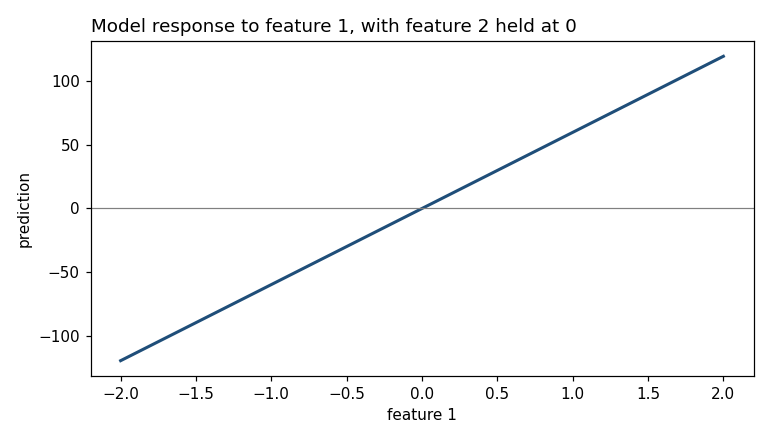


restored to random_state=42 : 23.589612
matches the original fit    : True


In [8]:
before = requests.get(BASE + '/predict/0.1/0.2', timeout=5).json()['prediction']
retrain = requests.post(BASE + '/retrain', json={'random_state': 7}, timeout=30).json()
after = requests.get(BASE + '/predict/0.1/0.2', timeout=5).json()['prediction']

print('prediction before retrain :', round(before, 6))
print('prediction after  retrain :', round(after, 6))
print('server reported changed   :', retrain['changed'])
print('the live route reflects it :', before != after, '(no restart happened)')
print()

plot = requests.get(BASE + '/plot', timeout=15)
print('GET /plot ->', plot.status_code, plot.headers.get('Content-Type'),
      f'{len(plot.content)} bytes')
Path('reports').mkdir(exist_ok=True)
Path('reports/plot_route.png').write_bytes(plot.content)
print('saved reports/plot_route.png')

try:
    plot.json()
except Exception as e:
    print(f'calling .json() on it raises {type(e).__name__}, as it should - it is a PNG')

from IPython.display import Image, display
display(Image(plot.content))

# Retrain back to the original seed. Without this the model.pkl that gets committed
# is the random_state=7 one, and the README's claim that it is the random_state=42
# model would be false. An artifact that contradicts its own documentation is the
# exact failure this stage is about.
restore = requests.post(BASE + '/retrain', json={'random_state': 42}, timeout=30).json()
restored = requests.get(BASE + '/predict/0.1/0.2', timeout=5).json()['prediction']
print()
print('restored to random_state=42 :', round(restored, 6))
print('matches the original fit    :', abs(restored - float(from_disk)) < 1e-9)

In [9]:
print('--- api.log, written by the server as it handled the calls above ---')
print(Path('api.log').read_text().strip()[-1400:])

--- api.log, written by the server as it handled the calls above ---
t HTTP/1.1" 400 -
2026-08-30 10:22:34,154 INFO POST /predict rejected: feature 0 is not a number: 'x'
2026-08-30 10:22:34,154 INFO 127.0.0.1 - - [30/Aug/2026 10:22:34] "POST /predict HTTP/1.1" 400 -
2026-08-30 10:22:34,154 INFO 127.0.0.1 - - [30/Aug/2026 10:22:34] "GET /predictt/1/2 HTTP/1.1" 404 -
2026-08-30 10:22:34,164 INFO GET /predict features=[0.1, 0.2] prediction=23.589612
2026-08-30 10:22:34,164 INFO 127.0.0.1 - - [30/Aug/2026 10:22:34] "GET /predict/0.1/0.2 HTTP/1.1" 200 -
2026-08-30 10:22:34,197 INFO POST /retrain seed=7 before=23.589612 after=12.722684
2026-08-30 10:22:34,197 INFO 127.0.0.1 - - [30/Aug/2026 10:22:34] "POST /retrain HTTP/1.1" 200 -
2026-08-30 10:22:34,198 INFO GET /predict features=[0.1, 0.2] prediction=12.722684
2026-08-30 10:22:34,198 INFO 127.0.0.1 - - [30/Aug/2026 10:22:34] "GET /predict/0.1/0.2 HTTP/1.1" 200 -
2026-08-30 10:22:34,247 INFO GET /plot rendered 26203 bytes
2026-08-30 10:22:

## 7. Write `README.md`

Written from the responses actually recorded above rather than typed by hand, so the
examples in it cannot drift from what the API really returns.

In [10]:
readme = f'''# Stage 13 Homework - Prediction API

A `LinearRegression` fitted on a two-feature synthetic dataset
(`make_regression(n_samples=100, n_features=2, noise=0.1, random_state=42)`), saved to
`model/model.pkl` with joblib. This app loads that file once at startup and serves
predictions from it over HTTP, so a program other than the notebook can use the model.

## Running it

    python app.py

The server starts on **http://127.0.0.1:5001** and loads `model/model.pkl` at startup.

**Why 5001 and not 5000.** macOS runs AirPlay Receiver on port 5000 from Monterey onward.
Flask either fails to bind or requests reach AirPlay and return 403, which looks like a
broken app. Override with `PORT=5002 python app.py` if 5001 is also busy.

## POST /predict

    curl -X POST http://127.0.0.1:{PORT}/predict \\
         -H "Content-Type: application/json" \\
         -d '{{"features": [0.1, 0.2]}}'

Response:

    {r_post.text.strip()}

## GET /predict/<f1>/<f2>

    curl http://127.0.0.1:{PORT}/predict/0.1/0.2

Response:

    {r_get.text.strip()}

Both routes use the same loaded model and return the same JSON shape, so a caller can
choose whichever suits it: a program posting JSON, or a person with a browser.

## Bad input

Every failure returns **HTTP 400** and a JSON body with an `error` key. Never a traceback,
and never HTML.

    curl http://127.0.0.1:{PORT}/predict/abc/0.2

Response:

    {r_bad.text.strip()}

| What you send | What comes back |
|---|---|
| `POST` with no `features` key | 400, `missing 'features'...` |
| `POST` with the wrong number of features | 400, `expected exactly 2 features, got N` |
| `POST` with a non-number in the list | 400, `feature i is not a number` |
| `GET /predict/abc/0.2` | 400, `feature 0 is not a number: 'abc'` |
| any unknown URL | 404 JSON listing the real routes |

The path parameters are declared as strings and converted by hand. Using Flask's
`<float:f1>` converter instead would make `/predict/abc/0.2` fail to match the route at
all, returning a **404 HTML page** rather than the JSON 400 required here.

## Extra routes

| Route | Method | Returns |
|---|---|---|
| `/health` | GET | `{{"status": "ok", "n_features": 2}}`. Used by the notebook to wait for startup |
| `/retrain` | POST | Refits on a new `random_state`, overwrites `model/model.pkl`, and swaps the model into the **running** process. Reports the prediction before and after |
| `/plot` | GET | A PNG of the model response curve. `image/png`, so do not call `.json()` on it |

`/retrain` rebinds the module-level `model` with `global`. Rewriting the pickle alone would
change nothing until the process restarted.

## Logging

Every request is appended to `api.log` with its input and its prediction, including the
rejected ones and why they were rejected.

## Files

    homework13_productization_submission.ipynb   this notebook
    app.py                                       the API, written by section 3
    model/model.pkl                              the saved model
    api.log                                      request log
    reports/plot_route.png                       the /plot output, saved for the record
    README.md                                    this file
'''

Path('README.md').write_text(readme, encoding='utf-8')
print(f'wrote README.md ({len(readme.splitlines())} lines)')

wrote README.md (85 lines)


## 8. Check, then shut the server down

Leaving a server bound to the port is how the next Restart-and-Run-All fails, so the last
thing this notebook does is stop the process it started.

In [11]:
checks = {
    'model/model.pkl exists': Path('model/model.pkl').exists(),
    'saved model predicts identically to the in-memory one': in_memory == from_disk,
    'app.py exists': Path('app.py').exists(),
    'app.py loads the model at module level, not in a route':
        "model = joblib.load(MODEL_PATH)" in Path('app.py').read_text().split('def ')[0],
    'POST /predict returned 200': r_post.status_code == 200,
    'GET /predict returned 200': r_get.status_code == 200,
    'both routes agree': r_post.json()['prediction'] == r_get.json()['prediction'],
    'bad path parameter returned 400': r_bad.status_code == 400,
    'bad call returned JSON, not HTML':
        'application/json' in r_bad.headers.get('Content-Type', ''),
    'retrain changed the live prediction': before != after,
    '/plot returned image/png': plot.headers.get('Content-Type') == 'image/png',
    'api.log has entries': Path('api.log').exists() and Path('api.log').stat().st_size > 0,
    'README.md exists': Path('README.md').exists(),
    'README quotes the real POST response': r_post.text.strip() in readme,
    'model.pkl on disk is back to the random_state=42 fit the README describes':
        abs(joblib.load('model/model.pkl').predict([[0.1, 0.2]])[0] - float(from_disk)) < 1e-9,
}
for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")
print()
print('all checks passed' if all(checks.values()) else 'SOMETHING FAILED - fix before submitting')

PASS  model/model.pkl exists
PASS  saved model predicts identically to the in-memory one
PASS  app.py exists
PASS  app.py loads the model at module level, not in a route
PASS  POST /predict returned 200
PASS  GET /predict returned 200
PASS  both routes agree
PASS  bad path parameter returned 400
PASS  bad call returned JSON, not HTML
PASS  retrain changed the live prediction
PASS  /plot returned image/png
PASS  api.log has entries
PASS  README.md exists
PASS  README quotes the real POST response
PASS  model.pkl on disk is back to the random_state=42 fit the README describes

all checks passed


In [12]:
server.terminate()
try:
    server.wait(timeout=10)
except subprocess.TimeoutExpired:
    server.kill()
    server.wait(timeout=10)
log.close()

print(f'server stopped, exit code {server.returncode}')
print(f'port {PORT} free again:', port_is_free(PORT))
print()
for p in ['app.py', 'model/model.pkl', 'README.md', 'api.log', 'reports/plot_route.png']:
    f = Path(p)
    print(f'  {p:<30} {f.stat().st_size if f.exists() else 0:>8} bytes')

server stopped, exit code -15
port 5001 free again: True

  app.py                             5678 bytes
  model/model.pkl                     601 bytes
  README.md                          3287 bytes
  api.log                            2804 bytes
  reports/plot_route.png            26203 bytes


### Save

Save as `homework13_productization_submission.ipynb`, with the output above visible. Commit
it alongside `app.py`, `model/model.pkl` and `README.md`.